## Bước 1 & 2: Import Thư Viện
Khai báo các thư viện cần thiết cho việc xử lý ảnh (OpenCV), tính toán toán học (NumPy, SciPy) và các mô hình Deep Learning (MTCNN, Keras).

In [1]:
import cv2
import numpy as np
import time
import os
from mtcnn import MTCNN
from tensorflow.keras.models import load_model
from scipy.spatial.distance import cosine
import keras
from keras_facenet import FaceNet
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score


# Cấu hình tắt cảnh báo debug của TensorFlow để terminal gọn gàng hơn
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("✅ Đã import toàn bộ thư viện thành công!")

✅ Đã import toàn bộ thư viện thành công!


## Bước 3: Khởi tạo Webcam
Sử dụng OpenCV để mở luồng video từ webcam. Cần đảm bảo camera hoạt động bình thường và không bị lỗi frame trước khi tiến hành nhận diện khuôn mặt.

In [2]:
def test_webcam_connection(camera_id: int = 0) -> None:
    """
    Kết nối và hiển thị luồng video trực tiếp từ Webcam.
    
    Args:
        camera_id (int): ID của thiết bị camera (mặc định là 0 cho camera tích hợp).
        
    Returns:
        None
    """
    cap = cv2.VideoCapture(camera_id)
    
    if not cap.isOpened():
        print(f"❌ Lỗi: Không thể truy cập Camera ID {camera_id}.")
        return

    print("✅ Camera đã sẵn sàng! Nhấn phím 'q' trên cửa sổ video để thoát.")
    
    # Biến hỗ trợ tính FPS (Frame Per Second)
    prev_time = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            print("❌ Lỗi: Mất tín hiệu từ camera.")
            break
            
        # Tính toán và hiển thị FPS
        current_time = time.time()
        fps = 1 / (current_time - prev_time)
        prev_time = current_time
        
        cv2.putText(frame, f"FPS: {int(fps)}", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
        cv2.imshow("Buoc 3: Kiem tra Webcam", frame)
        
        # Nhấn 'q' để thoát
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
    # Quy tắc bắt buộc: Giải phóng tài nguyên
    cap.release()
    cv2.destroyAllWindows()
    print("Đã đóng kết nối Camera an toàn.")

# Chạy thử nghiệm
test_webcam_connection(0)

✅ Camera đã sẵn sàng! Nhấn phím 'q' trên cửa sổ video để thoát.
Đã đóng kết nối Camera an toàn.


## Bước 4 & 5: Khởi tạo MTCNN và Phát hiện khuôn mặt
Sử dụng mô hình MTCNN để quét từng khung hình từ webcam. Quá trình này bao gồm việc chuyển đổi không gian màu từ BGR sang RGB, chạy dự đoán để lấy tọa độ khuôn mặt (Bounding Box) và vẽ khung nhận diện trực tiếp lên màn hình cùng độ tin cậy (Confidence Score).

In [3]:
def detect_faces_mtcnn(camera_id: int = 0, confidence_threshold: float = 0.9) -> None:
    """
    Sử dụng MTCNN để phát hiện khuôn mặt từ luồng video trực tiếp.
    
    Args:
        camera_id (int): ID của thiết bị camera.
        confidence_threshold (float): Ngưỡng độ tin cậy (0.0 đến 1.0) để lọc các nhận diện sai.
        
    Returns:
        None
    """
    # Bước 4: Khởi tạo mô hình MTCNN
    print("⏳ Đang khởi tạo mô hình MTCNN, vui lòng đợi...")
    detector = MTCNN()
    
    cap = cv2.VideoCapture(camera_id)
    if not cap.isOpened():
        print(f"❌ Lỗi: Không thể truy cập Camera ID {camera_id}.")
        return

    print("✅ Hệ thống phát hiện khuôn mặt sẵn sàng! Nhấn 'q' để thoát.")
    prev_time = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        # Tiền xử lý: Chuyển đổi BGR (OpenCV) sang RGB (MTCNN yêu cầu)
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Bước 5: Phát hiện khuôn mặt
        # results là danh sách các dictionary chứa tọa độ 'box', 'confidence'
        results = detector.detect_faces(rgb_frame)
        
        # Tính FPS
        current_time = time.time()
        fps = 1 / (current_time - prev_time) if (current_time - prev_time) > 0 else 0
        prev_time = current_time
        
        # Hiển thị FPS lên góc trái
        cv2.putText(frame, f"FPS: {int(fps)}", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        # Duyệt qua từng khuôn mặt phát hiện được
        for result in results:
            confidence = result['confidence']
            
            # Chỉ hiển thị nếu AI đủ tự tin (> 90%)
            if confidence >= confidence_threshold:
                x, y, w, h = result['box']
                
                # Sửa lỗi toạ độ âm (nếu khuôn mặt nằm sát rìa khung hình)
                x, y = max(0, x), max(0, y)
                
                # Vẽ khung chữ nhật (Màu Xanh dương, độ dày 2)
                cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
                
                # In thông số độ tin cậy ngay trên đầu khung
                cv2.putText(frame, f"{confidence:.2f}", (x, y - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
                
        # Hiển thị kết quả
        cv2.imshow("Buoc 4 & 5: MTCNN Face Detection", frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
    # Giải phóng tài nguyên
    cap.release()
    cv2.destroyAllWindows()
    print("Đã đóng kết nối Camera an toàn.")

# Gọi hàm chạy thử
detect_faces_mtcnn(0)

⏳ Đang khởi tạo mô hình MTCNN, vui lòng đợi...
✅ Hệ thống phát hiện khuôn mặt sẵn sàng! Nhấn 'q' để thoát.
Đã đóng kết nối Camera an toàn.


## Bước 6: 
### Bước 6.1: Thu thập dữ liệu
Sử dụng MTCNN làm công cụ tự động cắt khuôn mặt từ Webcam. Các ảnh sau khi cắt sẽ được chuẩn hóa về kích thước 100x100 pixel và lưu vào thư mục `dataset/raw/` để chuẩn bị cho quá trình huấn luyện mạng CNN.

In [11]:


def collect_face_data(person_name: str, num_images: int = 100, camera_id: int = 0) -> None:
    """
    Thu thập ảnh khuôn mặt từ webcam, tự động cắt bằng MTCNN và lưu thành dataset.
    
    Args:
        person_name (str): Tên người dùng (sẽ được dùng làm tên thư mục và Nhãn/Label).
        num_images (int): Số lượng ảnh cần thu thập (khuyến nghị >= 100 ảnh/người).
        camera_id (int): ID của camera.
    """
    # Tạo thư mục lưu trữ (Tuân thủ cấu trúc: ../dataset/raw/person_name)
    # Lưu ý: Dấu '..' dùng để lùi ra khỏi thư mục 'notebooks'
    save_path = os.path.join("..", "dataset", "raw", person_name)
    os.makedirs(save_path, exist_ok=True)
    
    print("⏳ Đang khởi tạo mô hình MTCNN...")
    detector = MTCNN()
    
    cap = cv2.VideoCapture(camera_id)
    if not cap.isOpened():
        print(f"❌ Lỗi: Không thể truy cập Camera ID {camera_id}.")
        return
        
    print(f"✅ Bắt đầu thu thập dữ liệu cho: {person_name.upper()}")
    print(f"📸 Vui lòng nhìn vào camera và xoay đầu nhẹ nhàng các hướng...")
    
    count = 0
    
    while count < num_images:
        ret, frame = cap.read()
        if not ret:
            break
            
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = detector.detect_faces(rgb_frame)
        
        # Chỉ lấy dữ liệu khi khung hình có ĐÚNG 1 khuôn mặt (tránh nhiễu)
        if len(results) == 1:
            res = results[0]
            
            # Chỉ cắt ảnh khi MTCNN rất tự tin (> 95%)
            if res['confidence'] > 0.95:
                x, y, w, h = res['box']
                x, y = max(0, x), max(0, y)
                
                # Bước 6: Cắt khuôn mặt (Crop)
                face_crop = frame[y:y+h, x:x+w]
                
                if face_crop.size != 0:
                    # Chuẩn hóa kích thước về 100x100
                    face_resized = cv2.resize(face_crop, (100, 100))
                    
                    # Lưu file ảnh
                    img_name = os.path.join(save_path, f"{person_name}_{count:04d}.jpg")
                    cv2.imwrite(img_name, face_resized)
                    count += 1
                    
                    # Vẽ khung xanh để thông báo đang chụp thành công
                    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
                    cv2.putText(frame, f"Da chup: {count}/{num_images}", (10, 30), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        cv2.imshow("Buoc 6: Data Collection", frame)
        
        # Đợi 100ms giữa các lần chụp để ảnh không bị quá giống nhau
        # Nhấn 'q' nếu muốn dừng đột ngột
        if cv2.waitKey(100) & 0xFF == ord('q'):
            print("⚠️ Đã dừng thu thập dữ liệu sớm.")
            break
            
    cap.release()
    cv2.destroyAllWindows()
    print(f"🎉 Hoàn thành! Đã lưu {count} ảnh khuôn mặt tại: {save_path}")

# Chạy thử nghiệm: Bỏ comment dòng dưới, thay "Ten_Cua_Ban" bằng tên viết liền không dấu
#collect_face_data(person_name="LT_Long", num_images=100)

### Bước 6.2: Cắt và chuẩn hóa dữ liệu hàng loạt
Sử dụng MTCNN để quét toàn bộ ảnh trong thư mục `dataset/raw/`. Hệ thống sẽ tự động phát hiện, cắt (crop) khuôn mặt, chuẩn hóa về kích thước 160x160 pixel và lưu trữ vào thư mục `dataset/aligned/` nhằm chuẩn bị đầu vào sạch nhất cho FaceNet.

In [ ]:
detector = MTCNN()
def preprocess_dataset(raw_dir: str = "../dataset/raw", aligned_dir: str = "../dataset/aligned", target_size: tuple = (160, 160)) -> None:
    """
    Duyệt qua thư mục raw, dùng MTCNN cắt khuôn mặt và lưu vào thư mục aligned.
    
    Args:
        raw_dir (str): Đường dẫn chứa ảnh gốc.
        aligned_dir (str): Đường dẫn lưu ảnh đã cắt.
        target_size (tuple): Kích thước chuẩn hóa cho FaceNet (160x160).
    """
    print("⏳ Đang khởi tạo mô hình MTCNN cho tác vụ tiền xử lý...")
    detector = MTCNN()
    
    # Tạo thư mục aligned nếu chưa có
    os.makedirs(aligned_dir, exist_ok=True)
    
    # Lấy danh sách các thư mục con (các classes/nhân vật)
    person_folders = [f for f in os.listdir(raw_dir) if os.path.isdir(os.path.join(raw_dir, f))]
    
    total_processed = 0
    total_failed = 0
    
    for person in person_folders:
        person_raw_path = os.path.join(raw_dir, person)
        person_aligned_path = os.path.join(aligned_dir, person)
        
        # Tạo thư mục tương ứng trong aligned
        os.makedirs(person_aligned_path, exist_ok=True)
        
        image_files = [f for f in os.listdir(person_raw_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        print(f"🔄 Đang xử lý {len(image_files)} ảnh cho: {person}...")
        
        for img_name in image_files:
            img_path = os.path.join(person_raw_path, img_name)
            img = cv2.imread(img_path)
            
            if img is None:
                continue
                
            # Chuyển BGR sang RGB cho MTCNN
            rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            results = detector.detect_faces(rgb_img)
            
            # Nếu tìm thấy ít nhất 1 khuôn mặt
            if results:
                # Ưu tiên lấy khuôn mặt có độ tin cậy cao nhất hoặc lớn nhất
                # Ở đây ta chọn khuôn mặt đầu tiên (thường là rõ nhất trong tập LFW)
                box = results[0]['box']
                x, y, w, h = max(0, box[0]), max(0, box[1]), box[2], box[3]
                
                # Cắt ảnh
                face_crop = img[y:y+h, x:x+w]
                
                # Kiểm tra tránh lỗi cắt ảnh rỗng
                if face_crop.size != 0:
                    face_resized = cv2.resize(face_crop, target_size)
                    
                    # Lưu file vào thư mục aligned
                    save_path = os.path.join(person_aligned_path, img_name)
                    cv2.imwrite(save_path, face_resized)
                    total_processed += 1
                else:
                    total_failed += 1
            else:
                total_failed += 1

    print(f"✅ Hoàn tất tiền xử lý!")
    print(f"📊 Thành công: {total_processed} ảnh | Thất bại (không thấy mặt): {total_failed} ảnh")

# Sửa lại đường dẫn (thêm chữ 'n' vào 'unknown')
unknown_raw_path = "../dataset/unknown" 
# Cập nhật tiếp đường dẫn này nếu nó nằm trong cùng cell
aligned_unknown_dir = "../dataset/aligned_unknown"
def preprocess_unknown(img_path):
    img = cv2.imread(img_path)
    if img is None: return None
    results = detector.detect_faces(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    if not results: return None
    box = results[0]['box']
    x, y, w, h = max(0, box[0]), max(0, box[1]), box[2], box[3]
    face = cv2.resize(img[y:y+h, x:x+w], (160, 160))
    return cv2.cvtColor(face, cv2.COLOR_RGB2BGR) # Lưu ý: trả về RGB để đồng bộ

# 3. Chạy vòng lặp xử lý
unknown_images = [f for f in os.listdir(unknown_raw_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
print(f"🔄 Đang xử lý {len(unknown_images)} ảnh unknown...")

for img_name in unknown_images:
    processed_face = preprocess_unknown(os.path.join(unknown_raw_path, img_name))
    if processed_face is not None:
        save_path = os.path.join(aligned_unknown_dir, img_name)
        cv2.imwrite(save_path, processed_face)

print(f"✅ thành công {aligned_unknown_dir}")

# Chạy đoạn code
preprocess_dataset()

🔄 Đang xử lý 8 ảnh unknown...
✅ Xong! Ảnh đã được lưu tại: ../dataset/aligned_unknown
⏳ Đang khởi tạo mô hình MTCNN cho tác vụ tiền xử lý...
🔄 Đang xử lý 60 ảnh cho: Colin_Powell...
🔄 Đang xử lý 79 ảnh cho: George_W_Bush...
🔄 Đang xử lý 51 ảnh cho: LT_Long...
🔄 Đang xử lý 66 ảnh cho: Tony_Blair...
✅ Hoàn tất tiền xử lý!
📊 Thành công: 252 ảnh | Thất bại (không thấy mặt): 4 ảnh


## Bước 7 & 8: Trích xuất đặc trưng với FaceNet
Sử dụng mô hình FaceNet đã tải trước đó để nạp toàn bộ ảnh từ thư mục `dataset/aligned/`, thực hiện suy luận (inference) để trích xuất ra các vector đặc trưng (Embedding 512 chiều) và lưu trữ chúng vào thư mục `dataset/embeddings/`.

In [14]:
from keras_facenet import FaceNet

# Khởi tạo mô hình FaceNet từ thư viện - Nó sẽ tự download model về thư mục cache hệ thống
# Bạn không cần phải lo về file .h5 hay lỗi nạp model nữa!
print("⏳ Đang khởi tạo mô hình FaceNet...")
embedder = FaceNet()
print("✅ Khởi tạo thành công!")

# Hàm get_embedding giờ đây cực kỳ đơn giản
def get_embedding(model, face_pixels):
    # Thư viện keras-facenet tự xử lý việc chuẩn hóa, chỉ cần đưa ảnh vào
    # face_pixels cần có dạng (160, 160, 3)
    embeddings = model.embeddings([face_pixels])
    return embeddings[0]

# Giờ bạn có thể chạy hàm save_embeddings() như bình thường
# Lưu ý: Trong hàm save_embeddings() của bạn, hãy truyền 'embedder' thay cho 'facenet_model'

⏳ Đang khởi tạo mô hình FaceNet...
✅ Khởi tạo thành công!


## Bước 9: Xây dựng cơ sở dữ liệu khuôn mặt (Embedding Database)
Chuyển đổi toàn bộ khuôn mặt đã chuẩn hóa trong thư mục `aligned` thành các vector đặc trưng (Embedding 512 chiều) bằng mô hình FaceNet. Sau đó, lưu trữ các vector này cùng với nhãn tương ứng (tên người) vào các file `.npy` để phục vụ cho việc tính toán khoảng cách so sánh trong bước nhận diện thời gian thực.

In [15]:
def save_embeddings_optimized(aligned_dir="../dataset/aligned", output_dir="../dataset/embeddings"):
    """
    Sử dụng thư viện keras-facenet để trích xuất embedding và lưu thành file .npy.
    """
    os.makedirs(output_dir, exist_ok=True)
    embeddings, labels = [], []
    
    # Lấy danh sách thư mục (tên nhân vật)
    person_folders = [f for f in os.listdir(aligned_dir) if os.path.isdir(os.path.join(aligned_dir, f))]
    
    for person in person_folders:
        person_path = os.path.join(aligned_dir, person)
        images = [f for f in os.listdir(person_path) if f.lower().endswith(('.jpg', '.png'))]
        
        print(f"🧬 Đang xử lý: {person} ({len(images)} ảnh)")
        for img_name in images:
            img = cv2.imread(os.path.join(person_path, img_name))
            if img is not None:
                # Keras-facenet yêu cầu ảnh RGB
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Trích xuất embedding (đã được thư viện tối ưu hóa)
                # embedder là đối tượng FaceNet() bạn vừa khởi tạo ở bước trước
                emb = embedder.embeddings([img_rgb])[0]
                
                embeddings.append(emb)
                labels.append(person)
            
    # Lưu file
    np.save(os.path.join(output_dir, "embeddings.npy"), np.array(embeddings))
    np.save(os.path.join(output_dir, "labels.npy"), np.array(labels))
    print(f"✅ Đã lưu thành công {len(embeddings)} vectors tại {output_dir}")

# Chạy lệnh này
save_embeddings_optimized()

🧬 Đang xử lý: Colin_Powell (60 ảnh)
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━

## Bước 10 & 11: So sánh khuôn mặt và Nhận diện người dùng
Viết hàm nhận diện khuôn mặt bằng cách trích xuất embedding từ ảnh webcam, sau đó tính khoảng cách Cosine với toàn bộ database đã lưu trữ. Nếu độ tương đồng vượt ngưỡng (ví dụ: 0.7), hệ thống sẽ hiển thị tên người dùng.

In [16]:
# 2. Load dữ liệu "cuốn danh bạ"
embeddings = np.load("../dataset/embeddings/embeddings.npy")
labels = np.load("../dataset/embeddings/labels.npy")

def recognize_faces_realtime(camera_id=0, threshold=0.7):
    detector = MTCNN()
    cap = cv2.VideoCapture(camera_id)
    
    print("🚀 Hệ thống nhận diện đang chạy! Nhấn 'q' để dừng.")
    
    while True:
        ret, frame = cap.read()
        if not ret: break

        frame = cv2.flip(frame, 1)
        
        # MTCNN hoạt động với ảnh RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = detector.detect_faces(rgb_frame)
        
        for res in results:
            if res['confidence'] > 0.95:
                x, y, w, h = res['box']
                # Cắt và resize khuôn mặt về chuẩn 160x160
                face_crop = cv2.resize(frame[max(0,y):y+h, max(0,x):x+w], (160, 160))
                
                # Trích xuất embedding từ khuôn mặt webcam
                img_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
                face_emb = embedder.embeddings([img_rgb])[0]
                
                # Tính khoảng cách Cosine với tất cả embeddings trong database
                # Cosine Similarity = 1 - Cosine Distance
                best_match = "Unknown"
                min_dist = 1.0 
                
                for i, db_emb in enumerate(embeddings):
                    dist = cosine(face_emb, db_emb)
                    if dist < (1 - threshold): 
                        if dist < min_dist:
                            min_dist = dist
                            best_match = labels[i]
                
                # Hiển thị kết quả lên Webcam
                label_text = f"{best_match} ({1 - min_dist:.2f})" if best_match != "Unknown" else "Unknown"
                color = (0, 255, 0) if best_match != "Unknown" else (0, 0, 255)
                
                cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
                cv2.putText(frame, label_text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        
        cv2.imshow("Face Recognition Lab", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'): break
            
    cap.release()
    cv2.destroyAllWindows()

# Chạy hệ thống
recognize_faces_realtime()

🚀 Hệ thống nhận diện đang chạy! Nhấn 'q' để dừng.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


## Bước 12: Đánh giá mô hình bằng Ma trận nhầm lẫn (Confusion Matrix)
Phân tích khả năng phân loại của hệ thống bằng cách so sánh nhãn dự đoán và nhãn thực tế trên tập dữ liệu đã biết. Ma trận này giúp trực quan hóa các trường hợp hệ thống nhận diện đúng, nhầm lẫn giữa các người dùng, hoặc phân loại sai thành "Unknown".

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


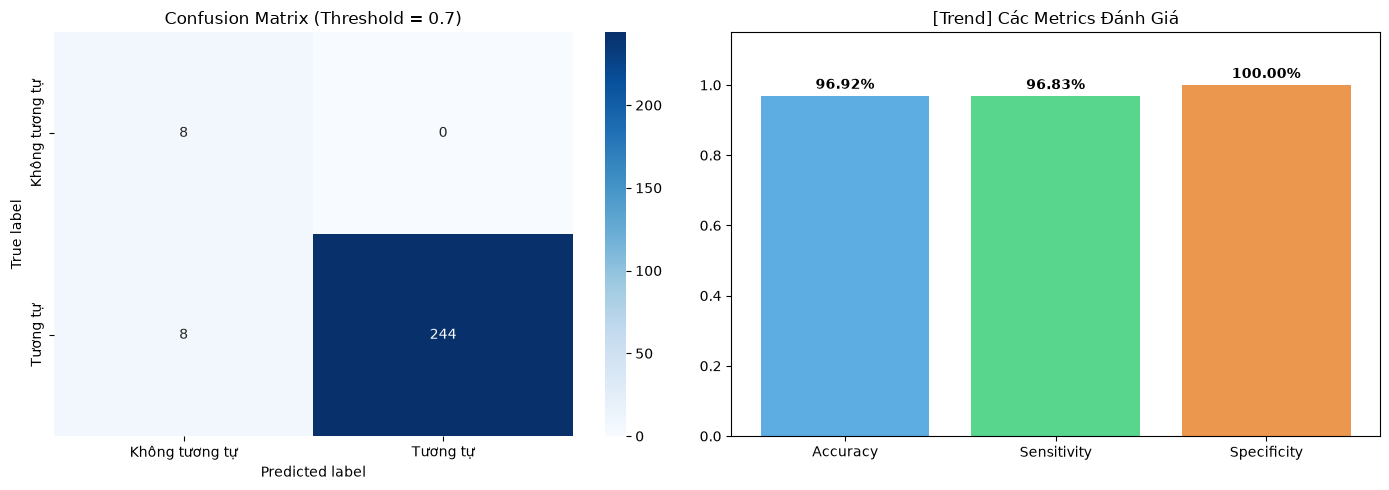

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
from scipy.spatial.distance import cosine
from keras_facenet import FaceNet

# Khởi tạo FaceNet
embedder = FaceNet()

# 1. Load database người quen (Positive)
embeddings_known = np.load("../dataset/embeddings/embeddings.npy")

# 2. Load và trích xuất vector cho người lạ (Negative)
unknown_dir = "../dataset/aligned_unknown"
embeddings_unknown = []
for img_name in os.listdir(unknown_dir):
    img = cv2.imread(os.path.join(unknown_dir, img_name))
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        emb = embedder.embeddings([img_rgb])[0]
        embeddings_unknown.append(emb)

# 3. Tạo tập nhãn và dự đoán
y_true = [1] * len(embeddings_known) + [0] * len(embeddings_unknown)
y_pred = []
threshold = 0.7

# Dự đoán người quen
for emb in embeddings_known:
    dists = [cosine(emb, db_emb) for db_emb in embeddings_known if not np.array_equal(emb, db_emb)]
    y_pred.append(1 if (1 - min(dists)) > threshold else 0)

# Dự đoán người lạ
for emb in embeddings_unknown:
    dists = [cosine(emb, db_known) for db_known in embeddings_known]
    y_pred.append(1 if (1 - min(dists)) > threshold else 0)

# 4. Tính toán Metrics
cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)
sensitivity = recall_score(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

# 5. Vẽ biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['Không tương tự', 'Tương tự'], 
            yticklabels=['Không tương tự', 'Tương tự'])
ax1.set_title(f'Confusion Matrix (Threshold = {threshold})')
ax1.set_xlabel('Predicted label')
ax1.set_ylabel('True label')

metrics = ['Accuracy', 'Sensitivity', 'Specificity']
values = [acc, sensitivity, specificity]
colors = ['#5DADE2', '#58D68D', '#EB984E']

ax2.bar(metrics, values, color=colors)
ax2.set_title('[Trend] Các Metrics Đánh Giá')
ax2.set_ylim(0, 1.15)
for i, v in enumerate(values):
    ax2.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Bước 13: Phân tích ngưỡng nhận diện (Threshold vs Accuracy Curve)
Xây dựng đường cong biểu diễn mối quan hệ giữa ngưỡng khoảng cách (threshold) và độ chính xác (accuracy) của mô hình. Bước này giúp xác định giá trị ngưỡng tối ưu, đảm bảo hệ thống đạt được sự cân bằng tốt nhất giữa tỷ lệ nhận diện đúng (True Positives) và tỷ lệ từ chối sai (False Negatives).

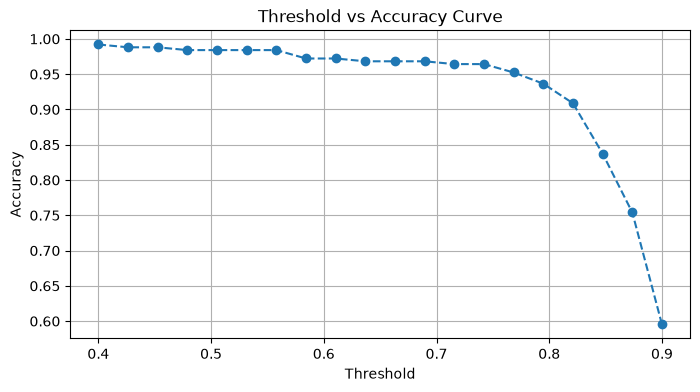

In [20]:
# 1. Load data ra biến toàn cục (Global variable) để dùng được cho mọi hàm
all_embeddings = np.load("../dataset/embeddings/embeddings.npy")
all_labels = np.load("../dataset/embeddings/labels.npy")

# 2. Hàm vẽ đồ thị bây giờ đã có thể truy cập 'all_embeddings'
def plot_threshold_curve():
    thresholds = np.linspace(0.4, 0.9, 20)
    accuracies = []
    
    for t in thresholds:
        correct = 0
        total = len(all_embeddings)
        for i, emb in enumerate(all_embeddings):
            # Tính khoảng cách với tất cả các vector khác trong DB
            dists = [cosine(emb, db_emb) for j, db_emb in enumerate(all_embeddings) if i != j]
            # Nếu khoảng cách gần nhất vượt qua ngưỡng t thì coi là nhận diện đúng
            if (1 - min(dists)) > t:
                correct += 1
        accuracies.append(correct / total)
        
    plt.figure(figsize=(8,4))
    plt.plot(thresholds, accuracies, marker='o', linestyle='--')
    plt.xlabel('Threshold')
    plt.ylabel('Accuracy')
    plt.title('Threshold vs Accuracy Curve')
    plt.grid(True)
    plt.show()

# Chạy lại hàm
plot_threshold_curve()